# Task 1 — Preattentive attributes and visual search

**CLO1 — Identify how the human brain processes visual information.**

Data: `data/stimuli_search.csv` (generated with `SEED = 42` — do not change it).

**The idea being tested.** A single preattentive attribute (hue *or* shape) is found in constant time, so
reaction time stays flat as distractors are added. A *conjunction* (red **and** circle) forces serial search,
so reaction time rises with set size. Section 2 runs that experiment on a real person; Section 4 reads the
slopes.

**How to use this notebook**

1. Run Sections 0–1 (no human needed).
2. In Section 2 set `RUN_EXPERIMENT = True`, run the cell, and hand the laptop to your participant. It saves
   `search_results.csv`.
3. Set `RUN_EXPERIMENT` back to `False`, then **Restart & Run All** so the submitted notebook has outputs and
   runs top to bottom.
4. Fill in every markdown cell marked **✏️ YOUR WRITE-UP**. The explanation is worth more than the chart.

## 0. Setup

In [1]:
from pathlib import Path
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA = Path("data/stimuli_search.csv")
RESULTS = Path("search_results.csv")

# Palette: one strong colour for the message, greys for context (Week 2 rule).
RED, BLUE, GREY, STRONG = "#d62728", "#1f77b4", "#aaaaaa", "#ee6677"
COLOURS = {"red": RED, "blue": BLUE}
MARKERS = {"circle": "o", "square": "s"}

stim = pd.read_csv(DATA)
print(stim.shape)
print(stim.groupby("condition")["trial"].nunique().rename("trials per condition"))
stim.head()

(2430, 10)
condition
colour         30
conjunction    30
shape          30
Name: trials per condition, dtype: int64


,trial,condition,set_size,target_present,item_index,x,y,colour,shape,is_target
0,1,colour,9,yes,0,0.2935,1.4610,blue,circle,no
1,1,colour,9,yes,1,0.2649,2.3593,blue,circle,no
2,1,colour,9,yes,2,1.5027,2.2633,blue,circle,no
3,1,colour,9,yes,3,1.3494,1.5749,blue,circle,no
4,1,colour,9,yes,4,2.5225,2.3602,blue,circle,no


## 1. Render a trial

In [2]:
def draw_trial(ax, trial_id, df=stim):
    """Draw one search trial on `ax`: items at x/y, coloured and shaped per the columns.
    No axes, no ticks, no title."""
    t = df[df["trial"] == trial_id]
    side = int(round(t["set_size"].iloc[0] ** 0.5))
    for shape, marker in MARKERS.items():
        for colour_name, colour in COLOURS.items():
            sub = t[(t["shape"] == shape) & (t["colour"] == colour_name)]
            if len(sub):
                ax.scatter(sub["x"], sub["y"], s=150, marker=marker, color=colour,
                           edgecolors="none")
    ax.set_xlim(0, side)
    ax.set_ylim(0, side)
    ax.set_aspect("equal")
    ax.set_axis_off()
    return ax

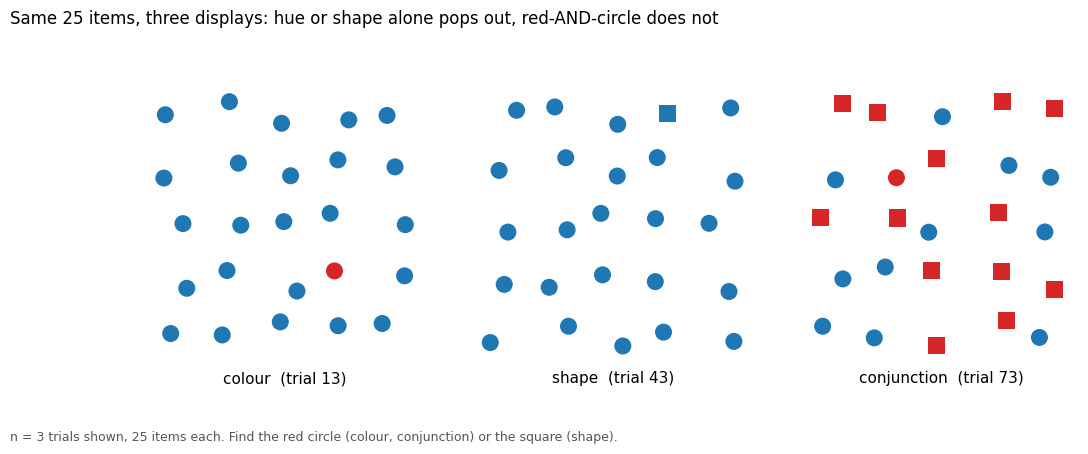

In [3]:
# Verification: one TARGET-PRESENT trial per condition at set_size = 25.
pick = (stim[(stim["set_size"] == 25) & (stim["target_present"] == "yes")]
        .groupby("condition")["trial"].first())

fig, axes = plt.subplots(1, 3, figsize=(12, 4.4))
for ax, cond in zip(axes, ["colour", "shape", "conjunction"]):
    draw_trial(ax, pick[cond])
    ax.text(0.5, -0.04, f"{cond}  (trial {pick[cond]})", transform=ax.transAxes,
            ha="center", va="top", fontsize=11)
fig.suptitle("Same 25 items, three displays: hue or shape alone pops out, "
             "red-AND-circle does not", x=0.01, ha="left", fontsize=12)
fig.text(0.01, 0.0, "n = 3 trials shown, 25 items each. Find the red circle (colour, conjunction) "
         "or the square (shape).", fontsize=9, color="#555555")
fig.savefig("task1_render_check.png", dpi=300, bbox_inches="tight")
plt.show()

**What the eye does here (read this *before* you time anyone).** Look at the three panels yourself.

- In `colour`, the lone red circle is found without scanning — the attribute is **hue**, a preattentive
  attribute that is well suited to a nominal "this one is different" message.
- In `shape`, the lone square is also found quickly — the attribute is **shape**.
- In `conjunction`, you probably felt yourself *hunting*. Every distractor shares exactly one of the target's
  two features, so neither "red" nor "circle" alone isolates it.

The chart-design rule that falls out of this: use **one** pre-attentive attribute for the thing you want
found, never a two-attribute combination.

## 2. Run the experiment on a real person

**Design.** `SET_SIZES` below gives 3 conditions × 3 set sizes × (1 target-present + 1 target-absent) =
**18 trials**, matching the brief's headline number. The brief's wording ("two per condition × set_size
cell") would literally give 30 trials across all five set sizes; set
`SET_SIZES = (9, 16, 25, 36, 49)` if you want that — five points per line gives a much more trustworthy
slope.

Trials are **blocked by condition** (so you can tell the participant the target before each block, not
during) with block order and trial order shuffled. The shuffling uses its own `random.Random(7)`; it does
**not** touch `SEED` in the download script.

Timing starts when the display is drawn and stops when the participant answers. Typing `y`/`n` + Enter adds
a few hundred ms of constant overhead to every trial — that shifts all lines up equally and does not change
the *slopes*, which is what matters here.

In [4]:
SET_SIZES = (9, 25, 49)          # or (9, 16, 25, 36, 49) for 30 trials
RUN_EXPERIMENT = False           # set True only when a participant is sitting there
PARTICIPANT = "a classmate"      # first name or "a classmate" is fine

TARGET_TEXT = {
    "colour": "the RED circle (all others are blue circles)",
    "shape": "the SQUARE (all others are circles)",
    "conjunction": "the item that is BOTH red AND a circle",
}

def pick_trials(df=stim, set_sizes=SET_SIZES, seed=7):
    rng = random.Random(seed)
    per_trial = df.drop_duplicates("trial")[["trial", "condition", "set_size", "target_present"]]
    blocks = {}
    for cond in ("colour", "shape", "conjunction"):
        chosen = []
        for s in set_sizes:
            for present in ("yes", "no"):
                pool = per_trial[(per_trial.condition == cond) & (per_trial.set_size == s)
                                 & (per_trial.target_present == present)]["trial"].tolist()
                chosen.append(rng.choice(pool))
        rng.shuffle(chosen)
        blocks[cond] = chosen
    order = list(blocks)
    rng.shuffle(order)
    return [(c, blocks[c]) for c in order]

plan = pick_trials()
print("Block order:", [c for c, _ in plan], "| total trials:", sum(len(t) for _, t in plan))

Block order: ['shape', 'conjunction', 'colour'] | total trials: 18


In [5]:
from IPython.display import clear_output

def run_experiment(plan, participant):
    rows = []
    for cond, trial_ids in plan:
        clear_output(wait=True)
        input(f"BLOCK: {cond.upper()}.\nTarget = {TARGET_TEXT[cond]}.\n"
              f"Tell the participant, then press Enter to start the block.")
        for tid in trial_ids:
            clear_output(wait=True)
            fig, ax = plt.subplots(figsize=(5, 5))
            draw_trial(ax, tid)
            plt.show()
            t0 = time.perf_counter()
            ans = ""
            while ans not in ("y", "n"):
                ans = input("Target present? (y/n): ").strip().lower()
            rt_ms = (time.perf_counter() - t0) * 1000
            meta = stim[stim.trial == tid].iloc[0]
            truth = meta.target_present == "yes"
            rows.append(dict(participant=participant, trial=tid, condition=cond,
                             set_size=int(meta.set_size), target_present=meta.target_present,
                             response=ans, correct=(ans == "y") == truth, rt_ms=round(rt_ms, 1)))
    clear_output(wait=True)
    out = pd.DataFrame(rows)
    out.to_csv(RESULTS, index=False)
    print(f"Saved {len(out)} trials to {RESULTS}")
    return out

if RUN_EXPERIMENT and not RESULTS.exists():
    results = run_experiment(plan, PARTICIPANT)
elif RESULTS.exists():
    print(f"{RESULTS} already exists - using it. Delete the file to re-run the experiment.")
else:
    print("No results yet. Set RUN_EXPERIMENT = True and run this cell with a participant.")

No results yet. Set RUN_EXPERIMENT = True and run this cell with a participant.


### ✏️ YOUR WRITE-UP — who, what, how

- **Participant** (first name / "a classmate"):
- **What you told them** (the exact instruction, and when you named the target):
- **Anything that could have affected the timings** (tired, learned the layout, interrupted, screen size):

## 3. Response time against set size (target-present only)

In [6]:
if not RESULTS.exists():
    print("Skipping: run Section 2 first so search_results.csv exists.")
else:
    res = pd.read_csv(RESULTS)
    print(f"{len(res)} trials; accuracy overall = {res['correct'].mean():.0%}")
    print(res.groupby(["condition", "target_present"])["correct"].mean().unstack().round(2))
    res.head()

Skipping: run Section 2 first so search_results.csv exists.


In [7]:
if RESULTS.exists():
    res = pd.read_csv(RESULTS)
    pres = res[(res.target_present == "yes") & (res.correct)]       # present AND answered correctly
    n_dropped = ((res.target_present == "yes") & (~res.correct)).sum()
    means = pres.groupby(["condition", "set_size"])["rt_ms"].mean().reset_index()

    # slope in ms per additional item
    slopes = {}
    for cond, g in means.groupby("condition"):
        slopes[cond], _ = np.polyfit(g["set_size"], g["rt_ms"], 1)
    slope_tbl = pd.Series(slopes, name="slope (ms / extra item)").round(1)
    print(slope_tbl.to_string())

    # ONE pop-out: conjunction in the strong colour. Others grey, told apart by marker + direct label,
    # so colour is not the only carrier of meaning.
    style = {"colour": dict(c=GREY, marker="o", ls="-"),
             "shape": dict(c=GREY, marker="s", ls="--"),
             "conjunction": dict(c=STRONG, marker="^", ls="-")}
    fig, ax = plt.subplots(figsize=(8, 5))
    for cond, g in means.groupby("condition"):
        st = style[cond]
        ax.plot(g["set_size"], g["rt_ms"], color=st["c"], marker=st["marker"], linestyle=st["ls"],
                lw=3 if cond == "conjunction" else 1.8)
        ax.annotate(f"{cond}  ({slopes[cond]:+.0f} ms/item)",
                    (g["set_size"].iloc[-1], g["rt_ms"].iloc[-1]),
                    xytext=(6, 0), textcoords="offset points", va="center", fontsize=10,
                    color="#222222" if cond == "conjunction" else "#666666")
    ax.set_xticks(sorted(means.set_size.unique()))
    ax.set_xlim(right=means.set_size.max() * 1.45)
    ax.set_ylim(bottom=0)
    ax.set_title(f"Conjunction search changed by {slopes['conjunction']:+.0f} ms per item; "
                 f"colour {slopes['colour']:+.0f}, shape {slopes['shape']:+.0f}", loc="left")
    ax.set_xlabel("Number of items on screen (set size)")
    ax.set_ylabel("Mean response time (ms)")
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    fig.text(0.01, -0.02, f"One reader ({res.participant.iloc[0]}). Target-present trials only, "
             f"correct answers only ({n_dropped} excluded). n = {len(pres)} trials.",
             fontsize=9, color="#555555")
    fig.savefig("task1_rt_vs_setsize.png", dpi=300, bbox_inches="tight")
    plt.show()

**Direct labels, not a legend:** each line is named at its right-hand end (Gestalt **connection / proximity**
— the label sits beside the line it names), so the reader does not hold a colour in working memory.
**Pop-out:** only the conjunction line is in colour; the two single-feature lines are grey and are told apart
by marker and dash, so colour is not the only carrier of meaning. Attribute used for the message:
**hue** (colour) for "this line is the one to look at", **position** for the quantitative values.

## 4. Read the slopes

In [8]:
if RESULTS.exists():
    print("Slope = ms per additional item (np.polyfit, degree 1)\n")
    print(slope_tbl.to_string())
    print()
    # Target-ABSENT kept separate, never averaged with present.
    absent = (res[(res.target_present == "no") & (res.correct)]
              .groupby(["condition", "set_size"])["rt_ms"].mean().unstack().round(0))
    print("Mean RT (ms), target-ABSENT, correct only:")
    print(absent.to_string())
    print()
    print("Mean RT (ms), target-PRESENT, correct only:")
    print(pres.groupby(["condition", "set_size"])["rt_ms"].mean().unstack().round(0).to_string())

### ✏️ YOUR WRITE-UP — what the slopes say

Replace the `___` with your own numbers and words. Do **not** make the data look tidier than it was.

- Colour slope = ___ ms/item → (flat / rising) → (parallel / serial).
- Shape slope = ___ ms/item → (flat / rising) → (parallel / serial).
- Conjunction slope = ___ ms/item → (flat / rising) → (parallel / serial).
- **Did any slope come out the "wrong" way?** If so, say so and give a reason — too few trials, the reader
  learned the layout, a cluttered display, the one-point-per-cell noise. (Each line here is fitted through
  only as many points as you have set sizes, each one a **single** target-present trial, so a single slow
  answer can tilt a slope. Say that.)
- **What this does not show:** one reader, a handful of trials, key-press overhead. Report the slope and say
  it is one reader; do not claim a general result.
- **Target-absent trials** (table above) are slower than target-present even for the single-feature
  conditions. Why? (Hint: what does the reader have to do before they can say "no"?)

## 5. Explain the conjunction result

### ✏️ YOUR WRITE-UP

**(a) In your own words:** why can the eye find "red" instantly and "circle" instantly, but not "red *and*
circle"? (Think about what is computed in parallel across the whole visual field, and what must be bound
together afterwards by attention, one item at a time.)

**(b) One chart where you asked a reader to do a conjunction search without realising it.** Name the chart,
the two attributes you combined (e.g. colour × marker shape in a scatter plot with a 5-colour × 4-shape
legend), and how you would redesign it so the reader only ever needs **one** attribute to find the thing
that matters.